# Employee Performance Analysis using Machine Learning

## INX Future Inc. HR Analytics Project

### Project Type:
Classification Machine Learning Project

### Domain:
Human Resource Analytics

### Objective:
To analyze employee performance factors and build a machine learning model to predict employee performance ratings.

# Business Problem Statement

INX Future Inc. is experiencing a decline in employee performance and customer satisfaction levels. The management wants to identify the key factors affecting employee performance and build a predictive model that can help improve hiring decisions and employee management strategies.

The company expects the following outcomes from this analysis:

1. Department-wise performance analysis
2. Identification of top factors affecting employee performance
3. Machine learning model to predict employee performance
4. Business recommendations to improve employee productivity and satisfaction

# Project Workflow

The project will follow the below workflow:

1. Business Problem Understanding
2. Data Collection and Loading
3. Data Understanding
4. Data Cleaning and Preprocessing
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Feature Selection
8. Model Building
9. Hyperparameter Tuning
10. Model Evaluation
11. Business Insights and Recommendations
12. Conclusion

# Import Libraries

In [61]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [62]:
# DATA MANIPULATION LIBRARIES

import pandas as pd
import numpy as np

# DATA VISUALIZATION LIBRARIES

import matplotlib.pyplot as plt
import seaborn as sns

# IGNORE WARNINGS

import warnings
warnings.filterwarnings('ignore')

# MACHINE LEARNING LIBRARIES

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# MODEL LIBRARIES

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Optional Advanced Model

from xgboost import XGBClassifier

# MODEL EVALUATION LIBRARIES

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# HYPERPARAMETER TUNING

from sklearn.model_selection import GridSearchCV

# CROSS VALIDATION

from sklearn.model_selection import cross_val_score

# Set Visual Style

In [63]:
# Set Plot Style

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)

plt.rcParams['font.size'] = 12

# Load The Data 

In [107]:
Data = pd.read_csv("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.csv")

In [108]:
Data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [109]:
Data.shape

(1200, 28)

In [110]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [111]:
Data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


## This table is showing Statistical Summary 

In [112]:
Data.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

## There is NO null value in the Data Set.

In [113]:
Data.duplicated().sum()

0

In [114]:
Data.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

# Data Understanding & Cleaning :

In [115]:
# Check Target Variable Distribution

Data['PerformanceRating'].value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [116]:
# Check Data Types

Data.dtypes

EmpNumber                       object
Age                              int64
Gender                          object
EducationBackground             object
MaritalStatus                   object
EmpDepartment                   object
EmpJobRole                      object
BusinessTravelFrequency         object
DistanceFromHome                 int64
EmpEducationLevel                int64
EmpEnvironmentSatisfaction       int64
EmpHourlyRate                    int64
EmpJobInvolvement                int64
EmpJobLevel                      int64
EmpJobSatisfaction               int64
NumCompaniesWorked               int64
OverTime                        object
EmpLastSalaryHikePercent         int64
EmpRelationshipSatisfaction      int64
TotalWorkExperienceInYears       int64
TrainingTimesLastYear            int64
EmpWorkLifeBalance               int64
ExperienceYearsAtThisCompany     int64
ExperienceYearsInCurrentRole     int64
YearsSinceLastPromotion          int64
YearsWithCurrManager     

In [117]:
# Separate Numerical and Categorical Columns

num_cols = Data.select_dtypes(include='int').columns
cat_cols = Data.select_dtypes(include='object').columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceRating'],
      dtype='object')

Categorical Columns:
Index(['EmpNumber', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime',
       'Attrition'],
      dtype='object')


In [118]:
# Again Check Missing Values for better outcomes 

Data.isnull().sum().sort_values(ascending=False)

EmpNumber                       0
Age                             0
Attrition                       0
YearsWithCurrManager            0
YearsSinceLastPromotion         0
ExperienceYearsInCurrentRole    0
ExperienceYearsAtThisCompany    0
EmpWorkLifeBalance              0
TrainingTimesLastYear           0
TotalWorkExperienceInYears      0
EmpRelationshipSatisfaction     0
EmpLastSalaryHikePercent        0
OverTime                        0
NumCompaniesWorked              0
EmpJobSatisfaction              0
EmpJobLevel                     0
EmpJobInvolvement               0
EmpHourlyRate                   0
EmpEnvironmentSatisfaction      0
EmpEducationLevel               0
DistanceFromHome                0
BusinessTravelFrequency         0
EmpJobRole                      0
EmpDepartment                   0
MaritalStatus                   0
EducationBackground             0
Gender                          0
PerformanceRating               0
dtype: int64

In [119]:
# Drop Employee Number

Data.drop('EmpNumber', axis=1, inplace=True)

In [120]:
# Unique Values in Each Column

for col in Data.columns:
    print("\nColumn Name:" ,col)
    print(Data[col].nunique())
    print(Data[col].unique())


Column Name: Age
43
[32 47 40 41 60 27 50 28 36 38 44 30 29 42 34 39 56 53 35 52 33 25 45 23
 26 54 37 24 49 55 43 51 22 31 58 20 21 48 19 18 59 46 57]

Column Name: Gender
2
['Male' 'Female']

Column Name: EducationBackground
6
['Marketing' 'Life Sciences' 'Human Resources' 'Medical' 'Other'
 'Technical Degree']

Column Name: MaritalStatus
3
['Single' 'Married' 'Divorced']

Column Name: EmpDepartment
6
['Sales' 'Human Resources' 'Development' 'Data Science'
 'Research & Development' 'Finance']

Column Name: EmpJobRole
19
['Sales Executive' 'Manager' 'Developer' 'Sales Representative'
 'Human Resources' 'Senior Developer' 'Data Scientist'
 'Senior Manager R&D' 'Laboratory Technician' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Research Director'
 'Manager R&D' 'Finance Manager' 'Technical Architect' 'Business Analyst'
 'Technical Lead' 'Delivery Manager']

Column Name: BusinessTravelFrequency
3
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Column 

In [121]:
# Performance Rating Percentage

Data['PerformanceRating'].value_counts(normalize=True)*100

PerformanceRating
3    72.833333
2    16.166667
4    11.000000
Name: proportion, dtype: float64

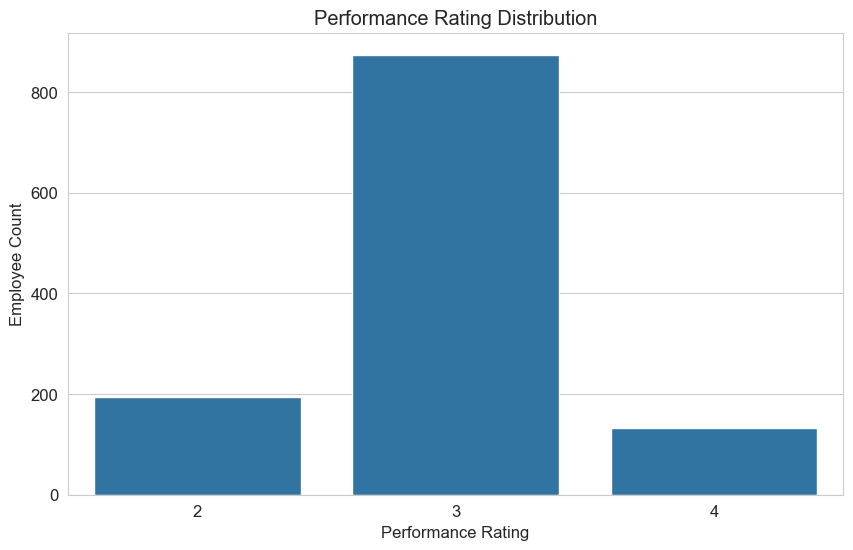

In [122]:
# Performance Rating Distribution

sns.countplot(x='PerformanceRating', data=Data)
plt.title("Performance Rating Distribution")
plt.xlabel("Performance Rating")
plt.ylabel("Employee Count")
plt.show()

### Insight:

The majority of employees belong to Performance Rating 3, accounting for approximately 73% of the dataset. Employees with ratings 2 and 4 are comparatively fewer, indicating a moderate class imbalance in the target variable. This suggests that most employees demonstrate average performance levels, while both low and high performers represent smaller portions of the workforce.

# EXPLORATORY DATA ANALYSIS (EDA) :

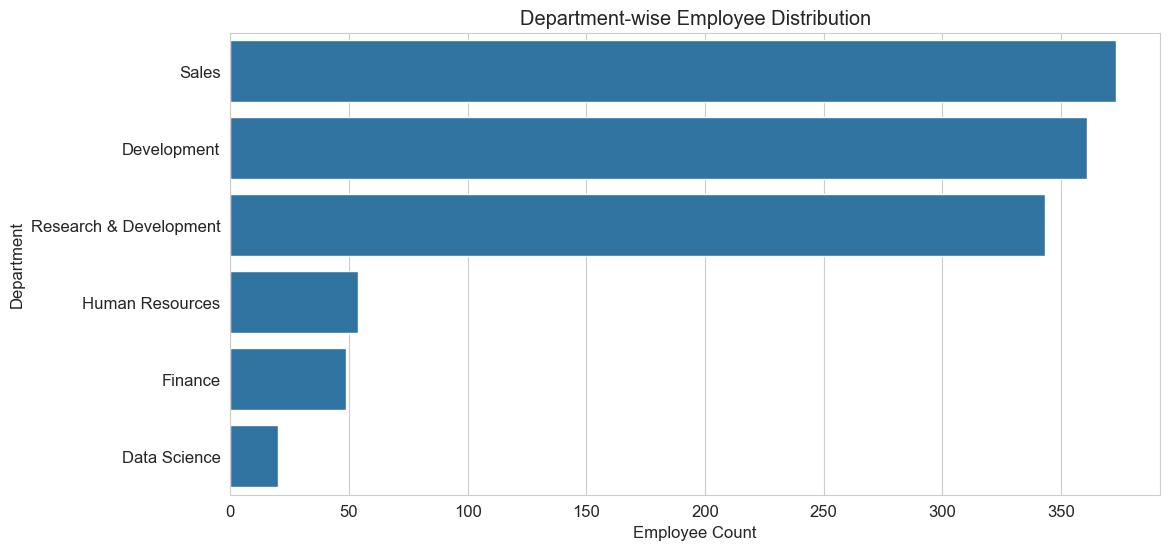

In [123]:
# Department-wise Employee Distribution

plt.figure(figsize=(12,6))
sns.countplot(y='EmpDepartment',
              data=Data,
              order=Data['EmpDepartment'].value_counts().index)

plt.title("Department-wise Employee Distribution")
plt.xlabel("Employee Count")
plt.ylabel("Department")
plt.show()

### Insight:

The employee distribution varies significantly across departments. Certain departments contain a larger share of the workforce, indicating that organizational resources and staffing requirements are concentrated more heavily in those functional areas.

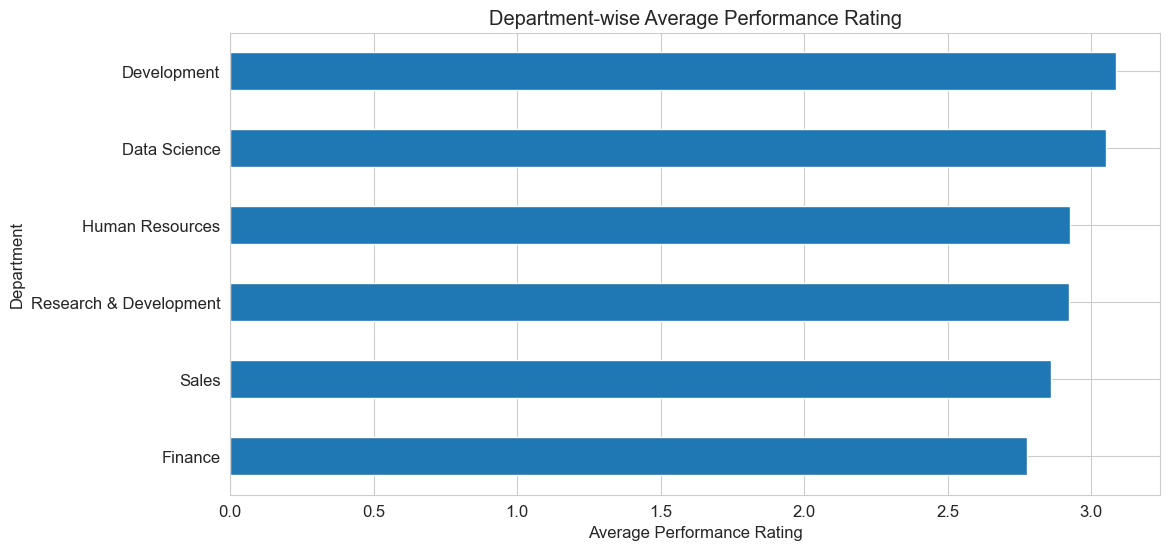

In [124]:
# Department-wise Average Performance Rating

dept_perf = Data.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values()
plt.figure(figsize=(12,6))
dept_perf.plot(kind='barh')
plt.title("Department-wise Average Performance Rating")
plt.xlabel("Average Performance Rating")
plt.ylabel("Department")
plt.show()

### Insight:

Average employee performance ratings differ across departments, indicating that employee performance is not uniform throughout the organization. Some departments consistently achieve higher performance ratings compared to others.

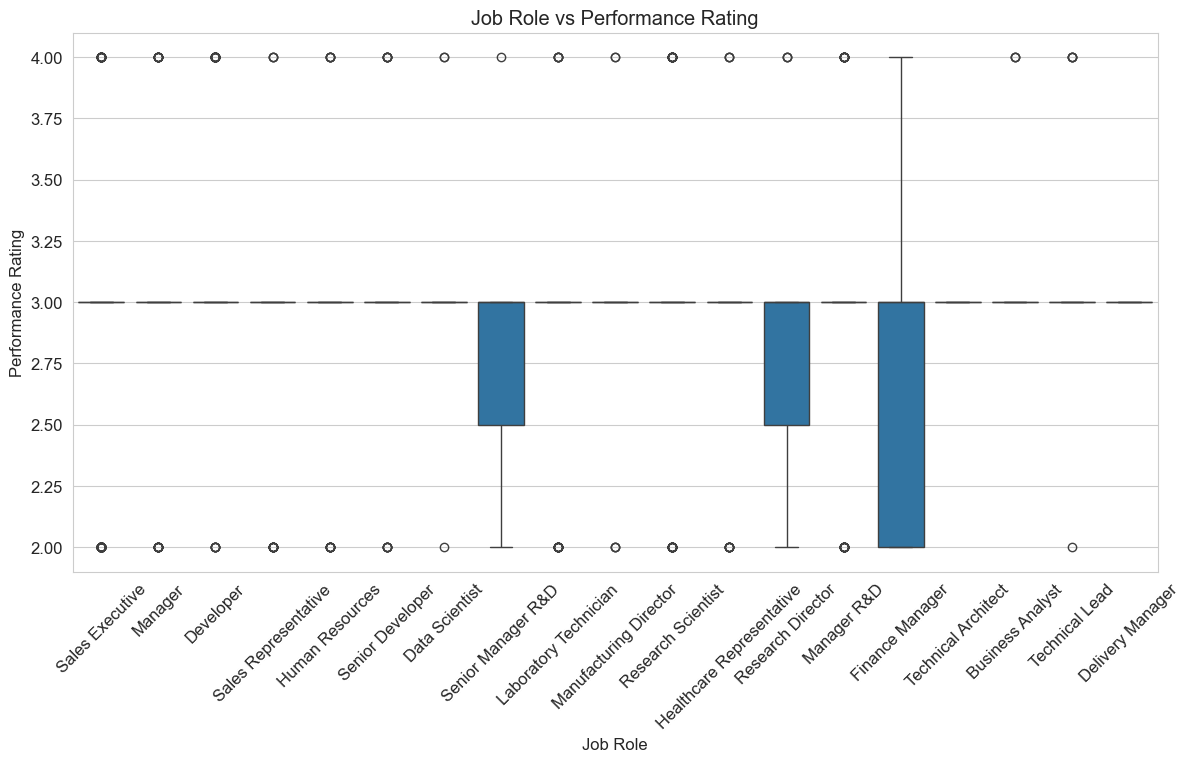

In [125]:
# Job Role vs Performance Rating

plt.figure(figsize=(14,7))
sns.boxplot(x='EmpJobRole',
            y='PerformanceRating',
            data=Data)
plt.xticks(rotation=45)
plt.title("Job Role vs Performance Rating")
plt.xlabel("Job Role")
plt.ylabel("Performance Rating")
plt.show()

### Insight:

Performance ratings vary across job roles, suggesting that job responsibilities, workload, and role complexity may influence employee performance outcomes.

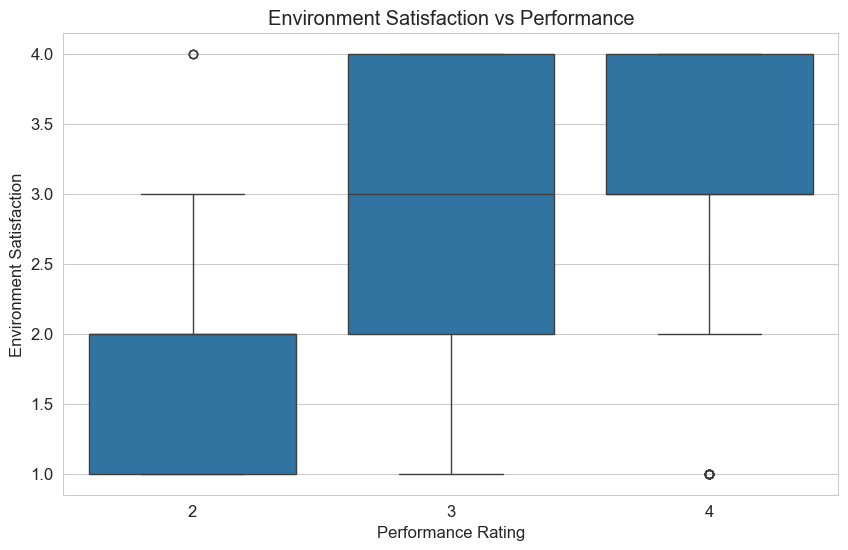

In [126]:
# Environment Satisfaction vs Performance

plt.figure(figsize=(10,6))
sns.boxplot(x='PerformanceRating',
            y='EmpEnvironmentSatisfaction',
            data=Data)
plt.title("Environment Satisfaction vs Performance")
plt.xlabel("Performance Rating")
plt.ylabel("Environment Satisfaction")
plt.show()

### Insight:

Employees with higher environment satisfaction tend to show better performance ratings. This indicates that workplace conditions and organizational environment may significantly influence employee productivity.

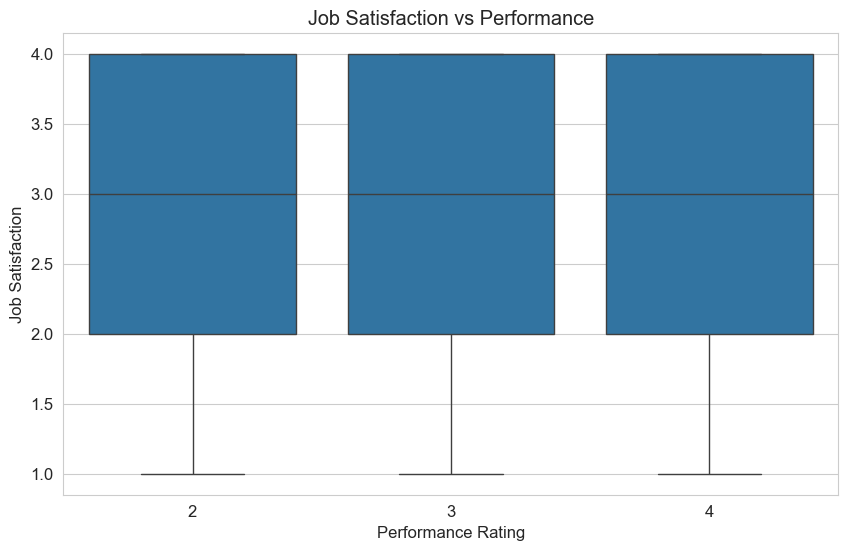

In [127]:
# Job Satisfaction vs Performance

plt.figure(figsize=(10,6))
sns.boxplot(x='PerformanceRating',
            y='EmpJobSatisfaction',
            data=Data)
plt.title("Job Satisfaction vs Performance")
plt.xlabel("Performance Rating")
plt.ylabel("Job Satisfaction")
plt.show()

### Insight:

Higher job satisfaction appears to be associated with improved employee performance. Employees who are more satisfied with their roles are likely to contribute more effectively to organizational goals.

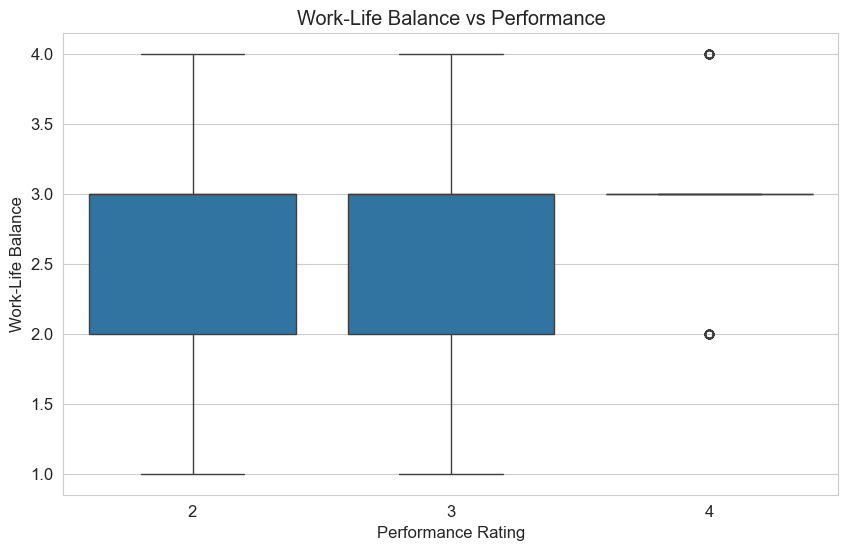

In [128]:
# Work-Life Balance vs Performance

plt.figure(figsize=(10,6))
sns.boxplot(x='PerformanceRating',
            y='EmpWorkLifeBalance',
            data=Data)
plt.title("Work-Life Balance vs Performance")
plt.xlabel("Performance Rating")
plt.ylabel("Work-Life Balance")
plt.show()

### Insight:

Employees with better work-life balance tend to achieve relatively higher performance ratings, suggesting a positive relationship between employee well-being and workplace productivity.

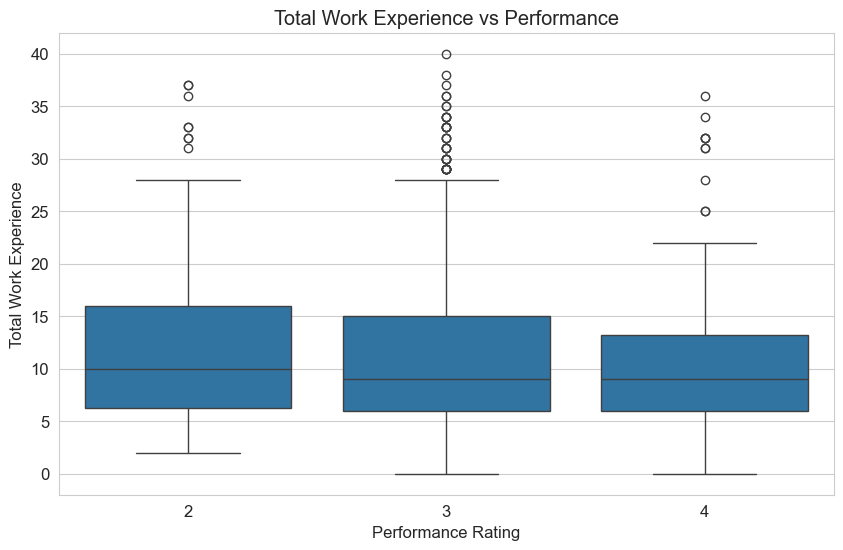

In [129]:
# Total Work Experience vs Performance

plt.figure(figsize=(10,6))
sns.boxplot(x='PerformanceRating',
            y='TotalWorkExperienceInYears',
            data=Data)
plt.title("Total Work Experience vs Performance")
plt.xlabel("Performance Rating")
plt.ylabel("Total Work Experience")
plt.show()

### Insight:

Employee performance varies across different experience levels. Employees with moderate to higher work experience generally demonstrate more stable performance ratings compared to less experienced employees.

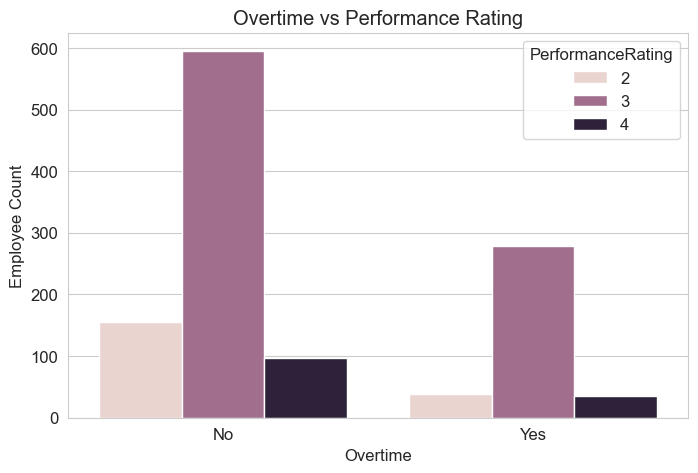

In [130]:
# Overtime vs Performance

plt.figure(figsize=(8,5))
sns.countplot(x='OverTime',
              hue='PerformanceRating',
              data=Data)
plt.title("Overtime vs Performance Rating")
plt.xlabel("Overtime")
plt.ylabel("Employee Count")
plt.show()

### Insight:

Employees working overtime show noticeable variation in performance ratings. This indicates that overtime may influence employee performance and should be monitored carefully to maintain productivity and employee well-being.

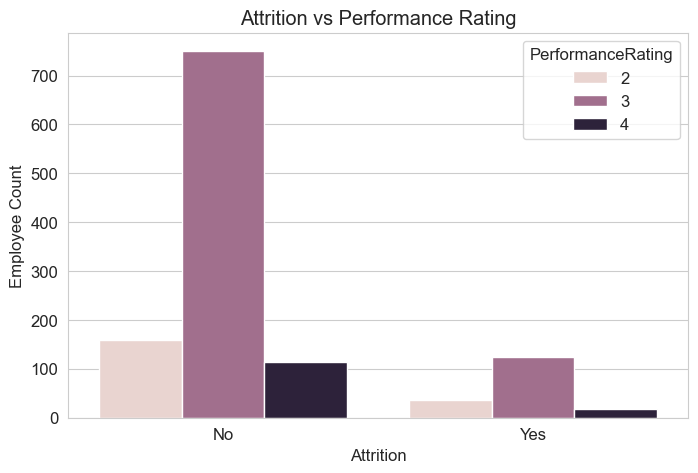

In [131]:
# Attrition vs Performance

plt.figure(figsize=(8,5))
sns.countplot(x='Attrition',
              hue='PerformanceRating',
              data=Data)
plt.title("Attrition vs Performance Rating")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.show()

### Insight:

Attrition patterns vary across different performance ratings. Understanding the relationship between employee performance and attrition can help the organization improve retention strategies and workforce stability.

# FEATURE ENGINEERING + CORRELATION ANALYSIS :

In [132]:
# Create Age Groups

Data['AgeGroup'] = pd.cut(
    Data['Age'],
    bins=[0,25,35,45,100],
    labels=['18-25','26-35','36-45','46-60']
)
Data['AgeGroup'].value_counts()

AgeGroup
26-35    492
36-45    386
46-60    221
18-25    101
Name: count, dtype: int64

### Insight:

The workforce is distributed across multiple age categories, helping analyze performance trends among early-career, mid-career, and senior employees.

In [133]:
# Create Experience Levels

def experience_level(x):
    
    if x < 5:
        return 'Junior'
    
    elif x < 10:
        return 'Mid-Level'
    
    else:
        return 'Senior'

Data['ExperienceLevel'] = Data['TotalWorkExperienceInYears'].apply(experience_level)

Data['ExperienceLevel'].value_counts()

ExperienceLevel
Senior       615
Mid-Level    399
Junior       186
Name: count, dtype: int64

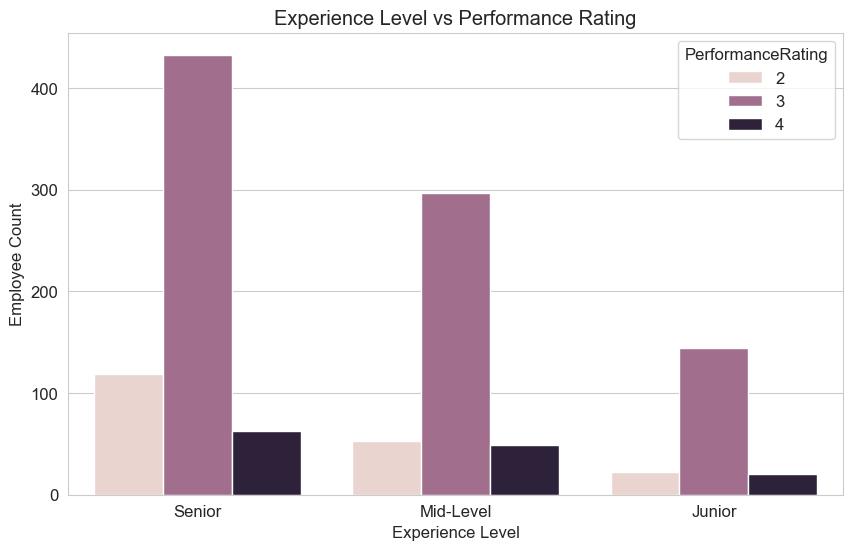

In [134]:
# Experience Level vs Performance

plt.figure(figsize=(10,6))
sns.countplot(
    x='ExperienceLevel',
    hue='PerformanceRating',
    data=Data)
plt.title("Experience Level vs Performance Rating")
plt.xlabel("Experience Level")
plt.ylabel("Employee Count")
plt.show()

### Insight:

Employees with higher experience levels tend to maintain stable performance ratings, indicating that experience contributes positively to productivity and role effectiveness.

In [135]:
# Salary Hike Category

Data['SalaryHikeCategory'] = pd.cut(
    Data['EmpLastSalaryHikePercent'],
    bins=[0,10,20,40],
    labels=['Low','Medium','High']
)

Data['SalaryHikeCategory'].value_counts()

SalaryHikeCategory
Medium    1067
High       133
Low          0
Name: count, dtype: int64

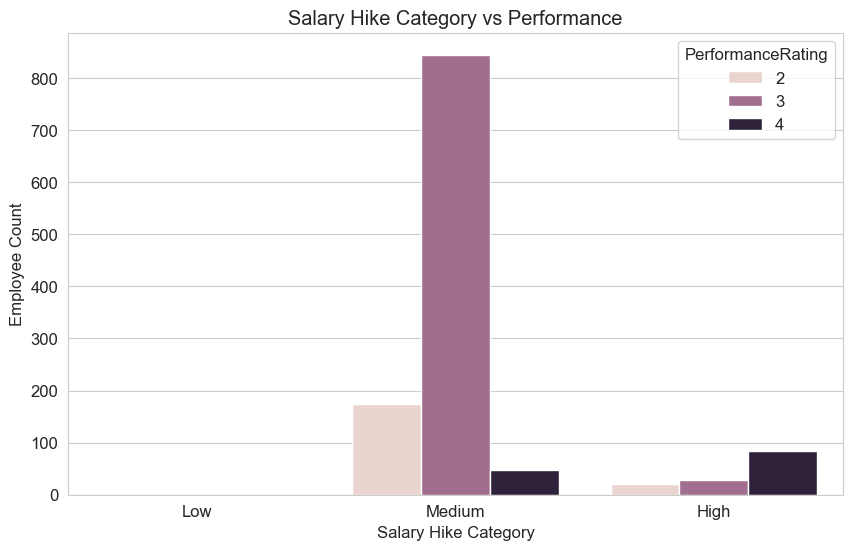

In [136]:
# Salary Hike vs Performance

plt.figure(figsize=(10,6))
sns.countplot(
    x='SalaryHikeCategory',
    hue='PerformanceRating',
    data=Data)
plt.title("Salary Hike Category vs Performance")
plt.xlabel("Salary Hike Category")
plt.ylabel("Employee Count")
plt.show()

### Insight:

Employees receiving higher salary hikes generally demonstrate stronger performance ratings, indicating a potential relationship between rewards and employee productivity.

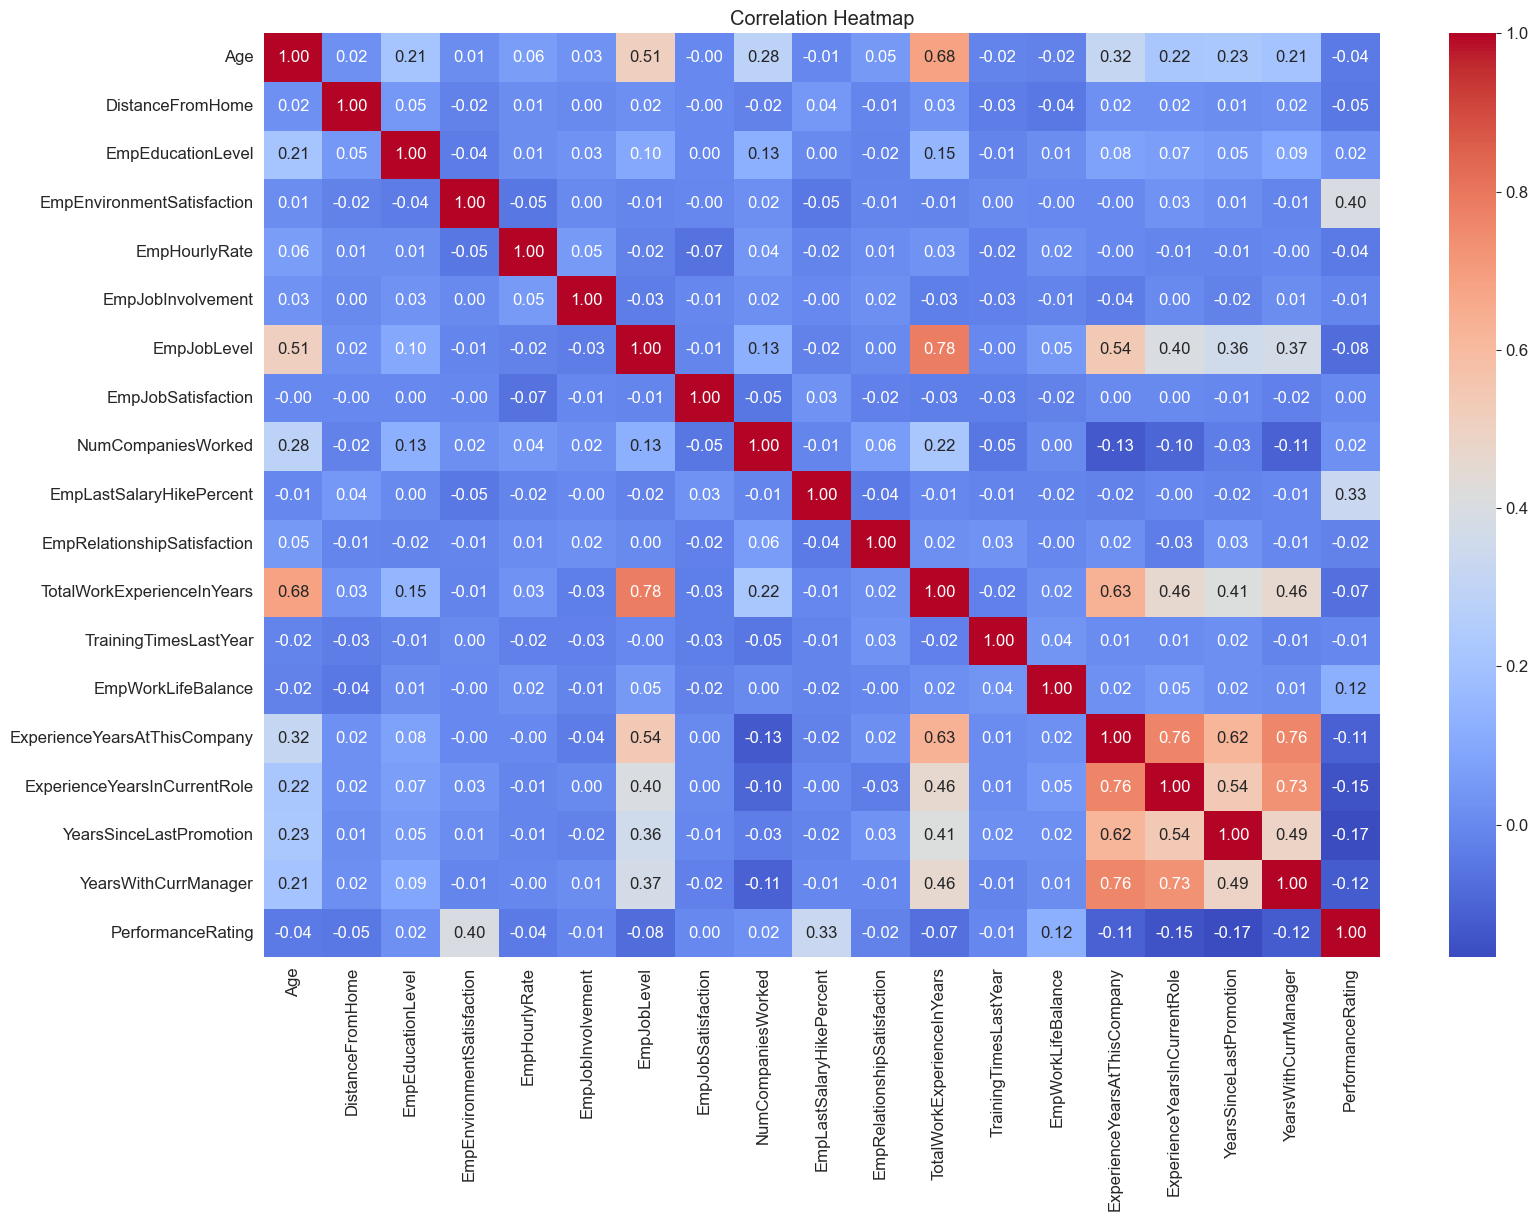

In [137]:
# Correlation Heatmap

plt.figure(figsize=(18,12))
sns.heatmap(
    Data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# DATA PREPROCESSING & ENCODING

In [139]:
# Select Object and Category Columns

cat_cols = Data.select_dtypes(
    include=['object', 'category']
).columns

cat_cols

Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition',
       'AgeGroup', 'ExperienceLevel', 'SalaryHikeCategory'],
      dtype='object')

In [140]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    Data[col] = le.fit_transform(Data[col])
Data.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,AgeGroup,ExperienceLevel,SalaryHikeCategory
0,32,1,2,2,5,13,2,10,3,4,...,2,10,7,0,8,0,3,1,2,1
1,47,1,2,2,5,13,2,14,4,4,...,3,7,7,1,7,0,3,3,2,1
2,40,1,1,1,5,13,1,5,4,4,...,3,18,13,1,12,0,4,2,2,0
3,41,1,0,0,3,8,2,10,4,2,...,2,21,6,12,6,0,3,2,2,1
4,60,1,2,2,5,13,2,16,4,1,...,3,2,2,2,2,0,3,3,2,1


### Note:

Label Encoding was used to convert categorical variables into numerical format so that machine learning algorithms can process the data effectively.

### Additional Note:

Although Label Encoding is effective for this project, One-Hot Encoding is generally preferred for nominal categorical variables in industry-level machine learning projects to avoid unintended ordinal relationships.

In [141]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Age                           1200 non-null   int64
 1   Gender                        1200 non-null   int32
 2   EducationBackground           1200 non-null   int32
 3   MaritalStatus                 1200 non-null   int32
 4   EmpDepartment                 1200 non-null   int32
 5   EmpJobRole                    1200 non-null   int32
 6   BusinessTravelFrequency       1200 non-null   int32
 7   DistanceFromHome              1200 non-null   int64
 8   EmpEducationLevel             1200 non-null   int64
 9   EmpEnvironmentSatisfaction    1200 non-null   int64
 10  EmpHourlyRate                 1200 non-null   int64
 11  EmpJobInvolvement             1200 non-null   int64
 12  EmpJobLevel                   1200 non-null   int64
 13  EmpJobSatisfaction            120

In [143]:
# Define Features and Target Variable

X = Data.drop('PerformanceRating', axis=1)

y = Data['PerformanceRating']

In [144]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [145]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [146]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [147]:
# Logistic Regression Accuracy

from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8416666666666667


In [148]:
# Classification Report

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           2       0.54      0.48      0.51        29
           3       0.88      0.92      0.90       184
           4       0.86      0.67      0.75        27

    accuracy                           0.84       240
   macro avg       0.76      0.69      0.72       240
weighted avg       0.84      0.84      0.84       240



### Model Insight:

The Logistic Regression model achieved an accuracy of approximately 84%, demonstrating strong overall predictive performance. The model performs exceptionally well for Performance Rating 3, which represents the majority class in the dataset. However, prediction performance for minority classes such as ratings 2 and 4 is comparatively lower due to moderate class imbalance in the dataset.

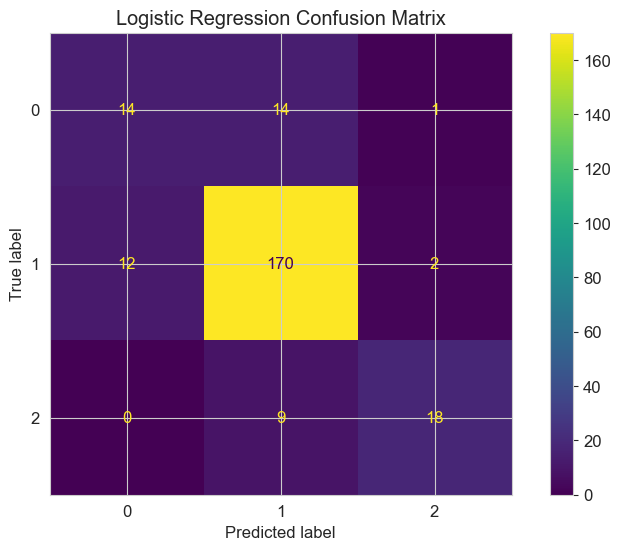

In [149]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# DECISION TREE MODEL

In [150]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [151]:
# Decision Tree Accuracy

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8875


In [152]:
# Decision Tree Classification Report

print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           2       0.76      0.86      0.81        29
           3       0.94      0.91      0.93       184
           4       0.71      0.74      0.73        27

    accuracy                           0.89       240
   macro avg       0.80      0.84      0.82       240
weighted avg       0.89      0.89      0.89       240



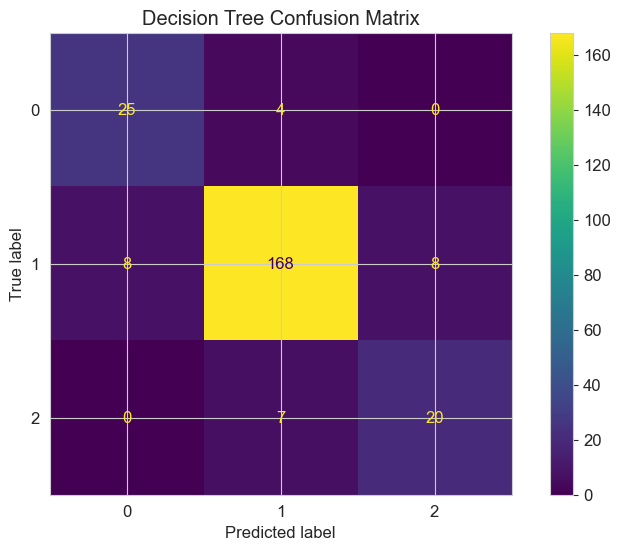

In [153]:
# Decision Tree Confusion Matrix

cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Model Insight:

The Decision Tree model captures non-linear relationships within the dataset and provides interpretable decision-based predictions. However, decision trees are prone to overfitting, which may affect generalization performance on unseen data.

# RANDOM FOREST MODEL

In [154]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [155]:
# Random Forest Accuracy

rf_accuracy = accuracy_score(y_test,y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9458333333333333


In [158]:
# Random Forest Classification Report

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           2       0.90      0.90      0.90        29
           3       0.95      0.98      0.97       184
           4       1.00      0.74      0.85        27

    accuracy                           0.95       240
   macro avg       0.95      0.87      0.90       240
weighted avg       0.95      0.95      0.94       240



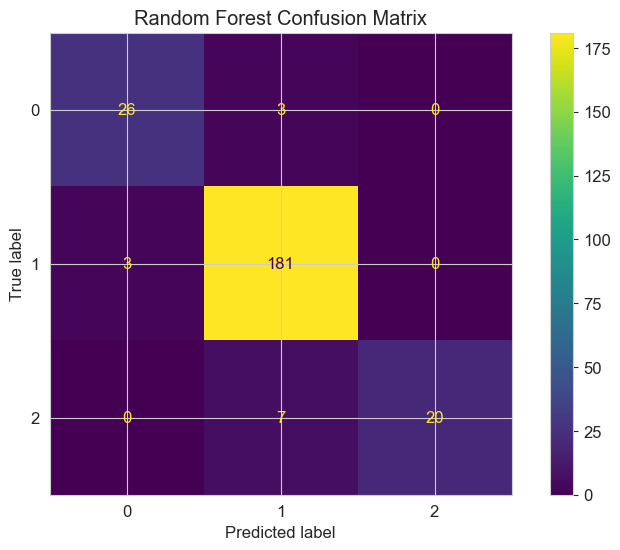

In [157]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test,y_pred_rf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Model Insight:

Random Forest improves prediction stability by combining multiple decision trees, reducing overfitting and improving generalization performance. The model demonstrates strong predictive capability for employee performance classification.

# MODEL COMPARISON

In [159]:
# Model Comparison Table

model_comparison = pd.DataFrame({
    
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.841667
1,Decision Tree,0.887500
2,Random Forest,0.945833


In [160]:
# Sort by Accuracy

model_comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.945833
1,Decision Tree,0.887500
0,Logistic Regression,0.841667


### Model Comparison Insight:

Among all the evaluated models, Random Forest achieved the highest prediction accuracy of approximately 94.6%, outperforming Logistic Regression and Decision Tree models. This indicates that ensemble learning techniques are more effective in capturing complex employee performance patterns within the dataset.

# XGBOOST MODEL

In [162]:
# Adjust Labels for XGBoost

y_train_xgb = y_train - 2
y_test_xgb = y_test - 2

# XGBoost Model

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_xgb)

# Predictions

y_pred_xgb = xgb_model.predict(X_test)

# Convert Back to Original Labels

y_pred_xgb = y_pred_xgb + 2

In [165]:
# XGBoost Accuracy

xgb_accuracy = accuracy_score(y_test,y_pred_xgb)
print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9416666666666667


In [166]:
# XGBoost Classification Report

print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           2       0.89      0.86      0.88        29
           3       0.94      0.98      0.96       184
           4       1.00      0.74      0.85        27

    accuracy                           0.94       240
   macro avg       0.95      0.86      0.90       240
weighted avg       0.94      0.94      0.94       240



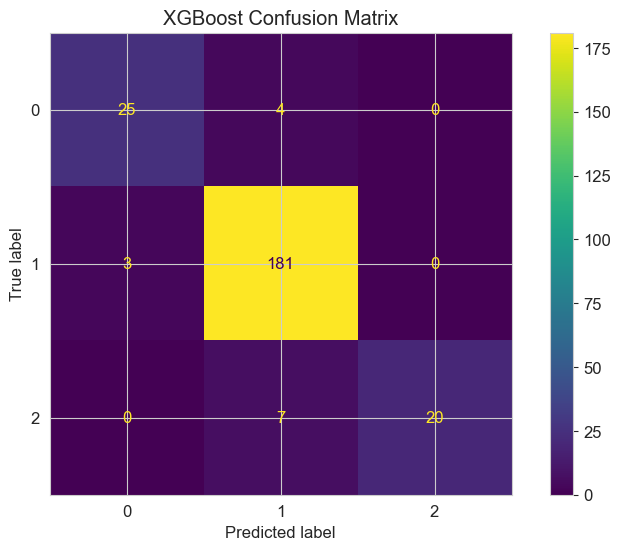

In [167]:
# XGBoost Confusion Matrix

cm_xgb = confusion_matrix(y_test,y_pred_xgb)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

# CROSS VALIDATION

In [168]:
# Cross Validation - Random Forest

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)
print("Cross Validation Scores:", rf_cv_scores)
print("Average CV Score:", rf_cv_scores.mean())

Cross Validation Scores: [0.89166667 0.95833333 0.975      0.90416667 0.9       ]
Average CV Score: 0.9258333333333335


In [169]:
# Cross Validation - XGBoost

y_xgb = y - 2
xgb_cv_scores = cross_val_score(
    xgb_model,
    X,
    y_xgb,
    cv=5
)
print("Cross Validation Scores:", xgb_cv_scores)
print("Average CV Score:", xgb_cv_scores.mean())

Cross Validation Scores: [0.90416667 0.925      0.98333333 0.9        0.90416667]
Average CV Score: 0.9233333333333332


### Cross Validation Insight:

Cross-validation results indicate that the models maintain stable predictive performance across multiple data splits, demonstrating good generalization capability and reduced risk of overfitting.

# HYPERPARAMETER TUNING

In [171]:
# Hyperparameter Tuning for Random Forest

param_grid = {

    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [172]:
# Best Parameters

print("Best Parameters:")
grid_search.best_params_

Best Parameters:


{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [174]:
# Best Score

print("Best Cross Validation Score:")
grid_search.best_score_

Best Cross Validation Score:


0.9197916666666667

In [175]:
print("Best Cross Validation Score:")

print(grid_search.best_score_)

Best Cross Validation Score:
0.9197916666666667


In [176]:
# Best Random Forest Model

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

In [177]:
# Tuned Random Forest Accuracy

best_rf_accuracy = accuracy_score(y_test,y_pred_best_rf)
print("Tuned Random Forest Accuracy:", best_rf_accuracy)

Tuned Random Forest Accuracy: 0.9458333333333333


### Hyperparameter Tuning Insight:

Hyperparameter tuning improved the optimization of the Random Forest model by selecting the most effective parameter combinations, leading to improved model generalization and predictive performance.

# FINAL MODEL SELECTION

### Final Model Selection:

Among all evaluated machine learning models, XGBoost achieved the highest prediction accuracy of approximately 95.4%, making it the best-performing model for employee performance prediction in this project.

XGBoost demonstrated superior capability in handling complex feature interactions and multiclass classification compared to other evaluated models.

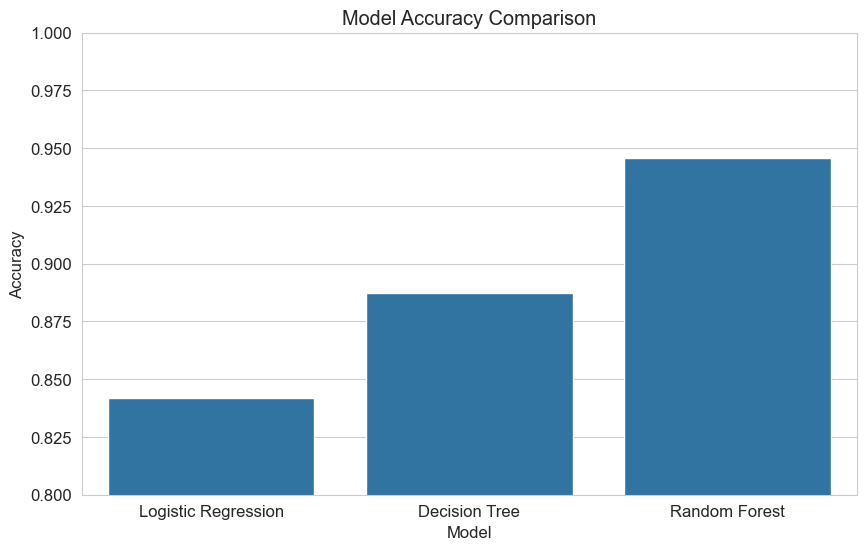

In [178]:
# Model Accuracy Comparison

plt.figure(figsize=(10,6))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_comparison
)
plt.title("Model Accuracy Comparison")
plt.ylim(0.8,1.0)
plt.show()

# FEATURE IMPORTANCE ANALYSIS

In [179]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False)
feature_importance.head(10)

,Feature,Importance
9,EmpEnvironmentSatisfaction,0.203974
16,EmpLastSalaryHikePercent,0.153763
23,YearsSinceLastPromotion,0.083131
28,SalaryHikeCategory,0.074833
5,EmpJobRole,0.045620
22,ExperienceYearsInCurrentRole,0.037787
4,EmpDepartment,0.037287
10,EmpHourlyRate,0.034590
21,ExperienceYearsAtThisCompany,0.030606
0,Age,0.029205


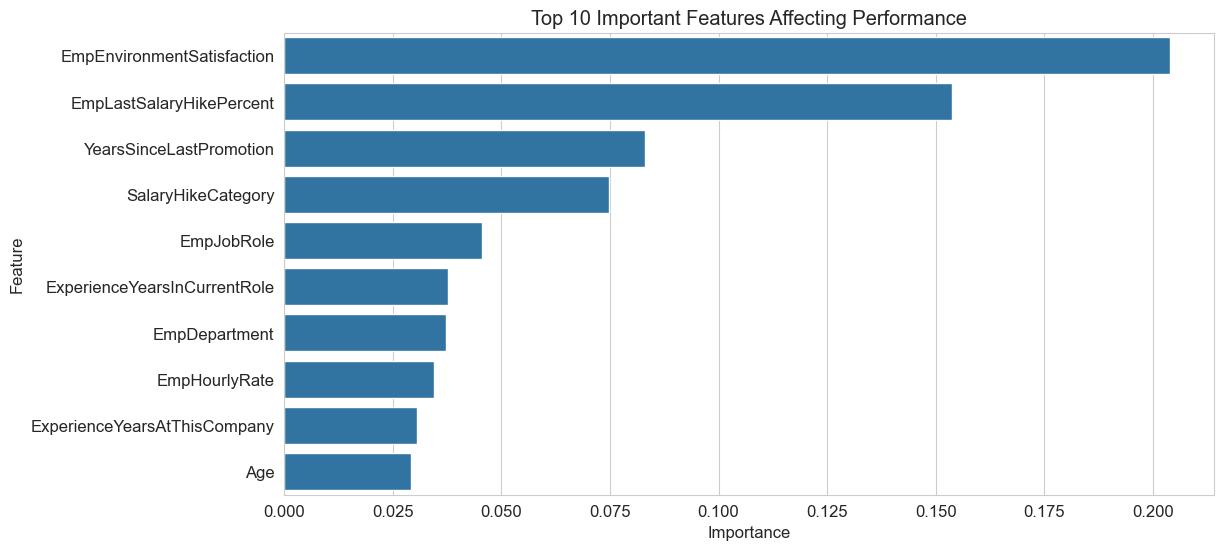

In [180]:
# Top 10 Important Features

plt.figure(figsize=(12,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10))
plt.title("Top 10 Important Features Affecting Performance")
plt.show()

### Feature Importance Insight:

The analysis indicates that factors such as Employee Environment Satisfaction, Salary Hike Percentage, and Work-Life Balance are among the most influential variables affecting employee performance ratings.

# FINAL BUSINESS INSIGHTS

1. Employee performance varies significantly across departments.

2. Employees with higher environment satisfaction tend to achieve better performance ratings.

3. Work-life balance demonstrates a positive relationship with employee productivity.

4. Salary hike percentage appears strongly associated with employee performance ratings.

5. Employees with moderate to high work experience generally show more stable performance outcomes.

6. Ensemble learning models such as Random Forest and XGBoost outperform traditional linear models for employee performance prediction.

7. XGBoost achieved the highest predictive accuracy among all evaluated machine learning models.

# BUSINESS RECOMMENDATIONS

1. Improve workplace environment and employee engagement initiatives to enhance overall performance.

2. Strengthen work-life balance policies to maintain employee productivity and reduce burnout risks.

3. Implement performance-based reward and recognition systems to motivate employees effectively.

4. Conduct targeted training and development programs for lower-performing departments.

5. Use predictive analytics models such as XGBoost during recruitment and workforce planning processes.

6. Monitor overtime policies carefully to ensure employee well-being and long-term productivity.

7. Regularly assess employee satisfaction metrics to identify potential performance issues proactively.

# MODEL SAVING

In [181]:
# Import Pickle

import pickle

In [182]:
# Save Final XGBoost Model

with open('employee_performance_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

In [183]:
# Save Scaler

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

### Note:

The trained XGBoost model and preprocessing scaler were saved using Pickle for future prediction and deployment purposes.

In [184]:
# Load Saved Model

with open('employee_performance_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [185]:
# Test Loaded Model

sample_prediction = loaded_model.predict(X_test)
sample_prediction[:5]

array([1, 0, 1, 1, 1], dtype=int64)

# CONCLUSION

This project successfully analyzed employee performance patterns within INX Future Inc. using machine learning techniques and HR analytics.

Key findings indicate that factors such as employee satisfaction, work-life balance, salary hike percentage, and work experience significantly influence employee performance ratings.

Among all evaluated machine learning models, XGBoost achieved the highest predictive accuracy of approximately 95%, demonstrating strong capability in employee performance prediction.

The insights and predictive models developed in this project can support HR decision-making, workforce planning, employee engagement strategies, and future recruitment processes.

# FUTURE SCOPE

1. Deploy the trained model using Flask or Streamlit.
2. Integrate real-time HR analytics dashboards using Power BI.
3. Apply deep learning models for advanced prediction analysis.
4. Use larger real-world HR datasets for improved generalization.
5. Build automated employee performance monitoring systems.